In [10]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from array import array
import torch
import networkx as nx
from scipy.spatial import Delaunay
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch.utils.data import ConcatDataset
import os
import glob
import torch.nn.functional as F
from torch_geometric.nn import GCNConv as gcn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [11]:
#purpose of this notebook is to further explore a GNN architecture to learn our new semantic labels. 
graph_file_directory = '/sdf/data/neutrino/summer25/ktwall/processed/' #directory containing graph datasets.
graph_file_paths = glob.glob(os.path.join(graph_file_directory, "*.pt")) 

In [3]:
#Lets create a training set that contains the first 30 files worth of graphs:
train_file_paths = graph_file_paths[0:90]
training_datasets_list = []
for i, train_path in enumerate(train_file_paths):
    training_datasets_list.append(torch.load(train_path))
    if (i % 10 == 0):
        print(i)
    
training_dataset = ConcatDataset(training_datasets_list)
print('loaded training dataset')

#Validation set that contains 5 files worth of graphs
validation_file_paths = graph_file_paths[90:95]
validation_datasets_list = []
for validation_path in validation_file_paths:
    validation_datasets_list.append(torch.load(validation_path))

validation_dataset = ConcatDataset(validation_datasets_list)
print('loaded validation dataset')



/lscratch/ktwall/tmp/ipykernel_2124143/855497931.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  training_datasets_list.append(torch.load(train_path))


0
10
20
30
40
50
60
70
80
loaded training dataset


/lscratch/ktwall/tmp/ipykernel_2124143/855497931.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  validation_datasets_list.append(torch.load(validation_path))


loaded validation dataset


In [12]:
#Testing set that contains 5 files worth of graphs
testing_file_paths = graph_file_paths[95:100]
testing_datasets_list = []
for testing_path in testing_file_paths:
    testing_datasets_list.append(torch.load(testing_path))

testing_dataset = ConcatDataset(testing_datasets_list)
print('loaded testing dataset')

/lscratch/ktwall/tmp/ipykernel_2124143/369356541.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  testing_datasets_list.append(torch.load(testing_path))


loaded testing dataset


In [13]:
print(testing_file_paths)

['/sdf/data/neutrino/summer25/ktwall/processed/file_2504_graphs.pt', '/sdf/data/neutrino/summer25/ktwall/processed/file_2468_graphs.pt', '/sdf/data/neutrino/summer25/ktwall/processed/file_2535_graphs.pt', '/sdf/data/neutrino/summer25/ktwall/processed/file_2553_graphs.pt', '/sdf/data/neutrino/summer25/ktwall/processed/file_2499_graphs.pt']


In [6]:
#Let's create our data loaders here
batch = 50
#train
training_data_loader = DataLoader(training_dataset, batch_size = batch, drop_last = True, shuffle=True, num_workers=2)
print(f'Training on {len(training_data_loader)*training_data_loader.batch_size} total graphs')

#validate
validation_data_loader = DataLoader(validation_dataset, batch_size = batch, drop_last = True, shuffle=True)
print(f'Validating on {len(validation_data_loader)*validation_data_loader.batch_size} total graphs')



Training on 226500 total graphs
Validating on 12000 total graphs


In [14]:
#test
testing_data_loader = DataLoader(testing_dataset, batch_size = 100, drop_last = True, shuffle=True)
print(f'Training on {len(testing_data_loader)*testing_data_loader.batch_size} total graphs')

Training on 12500 total graphs


In [64]:
#Lets compile some node level statistics on our training data. 
tracks = 0
others = 0
total = 0
for data in training_dataset:
    labels = data.y
    total += len(data.y)
    uniques, counts = np.unique(labels, return_counts=True)
    for i, label in enumerate(uniques):
        if label == 0:
            tracks += counts[i]
        if label == 1:
            others += counts[i]

sizes = np.array([tracks, others])
categories = ['Tracks', 'Others']
colors = ['blue', 'red']

plt.pie(sizes, labels=categories, colors = colors, autopct='%.1f%%')
plt.title("Truth Label Fraction")


In [15]:
#Now, the architecture. GCN Based

class Arthur1(torch.nn.Module):
    def __init__(self, in_channels, hc1, hc2, hc3, fc1, fc2, fc3, out_channels): # we define all of the convolutions and layers here
        super(Arthur1, self).__init__()
        self.convolution1 = gcn(in_channels, hc1) 
        self.bn1 = torch.nn.BatchNorm1d(hc1)
        self.convolution2 = gcn(hc1, hc2) 
        self.bn2 = torch.nn.BatchNorm1d(hc2)
        self.convolution3 = gcn(hc2, hc3)
        self.bn3 = torch.nn.BatchNorm1d(hc3)
        self.linear1 = torch.nn.Linear(hc3, fc1) 
        self.linear2 = torch.nn.Linear(fc1, fc2)
        self.linear3 = torch.nn.Linear(fc2, fc3)
        self.linear4 = torch.nn.Linear(fc3, out_channels)

        self.parameter_init()

    def forward(self, x, edge_index): #then apply them in the forward defintion. 
        x = self.convolution1(x, edge_index) #apply first convolution. Here we are actually applying the inputs. 
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.convolution2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.convolution3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.linear1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.linear2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.linear3(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.linear4(x)
        x = F.relu(x)
        return(x) #going to change the model to apply the log softmax at inference. 

    def parameter_init(self):
        for module in self.modules():
            if isinstance(module, (torch.nn.Linear)):
                torch.nn.init.kaiming_uniform_(module.weight, nonlinearity='relu') #set weights to random from uniform weighted on Relu
                if module.bias is not None:
                    torch.nn.init.zeros_(module.bias) #set biases to zero (if there are any)
            
                
            
    

In [9]:
class Arthur2(torch.nn.Module):
    def __init__(self, in_channels, hc1, hc2, hc3, hc4, fc1, fc2, fc3, fc4, out_channels): # we define all of the convolutions and layers here
        super(Arthur2, self).__init__()
        self.convolution1 = gcn(in_channels, hc1) 
        self.bn1 = torch.nn.BatchNorm1d(hc1)
        self.convolution2 = gcn(hc1, hc2) 
        self.bn2 = torch.nn.BatchNorm1d(hc2)
        self.convolution3 = gcn(hc2, hc3)
        self.bn3 = torch.nn.BatchNorm1d(hc3)
        self.convolution4 = gcn(hc3, hc4)
        self.bn4 = torch.nn.BatchNorm1d(hc4)
        self.linear1 = torch.nn.Linear(hc4, fc1) 
        self.linear2 = torch.nn.Linear(fc1, fc2)
        self.linear3 = torch.nn.Linear(fc2, fc3)
        self.linear4 = torch.nn.Linear(fc3, fc4)
        self.linear5 = torch.nn.Linear(fc4, out_channels)

        self.parameter_init()

    def forward(self, x, edge_index): #then apply them in the forward defintion. 
        x = self.convolution1(x, edge_index) #apply first convolution. Here we are actually applying the inputs. 
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.convolution2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.convolution3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.convolution4(x, edge_index)
        x = self.bn4(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.linear1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.linear2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.linear3(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.linear4(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.linear5(x)
        x = F.relu(x)
        
        return(x) #going to change the model to apply the log softmax at inference. 

    def parameter_init(self):
        for module in self.modules():
            if isinstance(module, (torch.nn.Linear)):
                torch.nn.init.kaiming_uniform_(module.weight, nonlinearity='relu') #set weights to random from uniform weighted on Relu
                if module.bias is not None:
                    torch.nn.init.zeros_(module.bias) #set biases to zero (if there are any)

In [69]:
import csv

def run_train(model, training_loader_, validation_loader_, num_iterations = 100, log_dir = '/sdf/data/neutrino/summer25/ktwall/logs_Arthur2', log_prefix= 'hero_run2', optimizer='SGD', lr=0.001, device = None):
    train_log_name = f'{log_dir}/{log_prefix}train.csv'
    #Lets just use cross entropy
    criterion = torch.nn.CrossEntropyLoss()
    optimizer_fn = getattr(torch.optim,optimizer)
    optimizer = optimizer_fn(model.parameters(), lr=lr)
    # Loop over the entire dataset until the requested number of iterations is reached (pulling this section from Francois guide)
    iteration = 0
    epoch_at_valid = []
    validation_acc = []
    with open(train_log_name, 'w') as csvfile:
        # Initialize CSV writer
        writer = csv.writer(csvfile)
        writer.writerow(['iter', 'epoch', 'loss'])
        while iteration < num_iterations:
            # Loop over data in the loader (one epoch)
            model.train()
            for training_data in training_loader_:
                
                #very rudimentary test of accuracy pre any training iteration = 0 
                if (iteration == 0):
                    with torch.no_grad():
                        i = 0
                        total_correct = 0
                        for validation_data in validation_loader_:
                            validation_out = model(validation_data.x, validation_data.edge_index)
                            inference = F.log_softmax(validation_out, dim=1)
                            n_correct = torch.sum(inference.argmax(dim=1) == (validation_data.y))
                            i += len(validation_data.y)
                            total_correct += n_correct
                        print(f"Validation at epoch {iteration/len(training_loader_)}, accuracy = {total_correct/i}") 
                        epoch_at_valid.append(iteration/len(training_loader_))
                        validation_acc.append(total_correct/i)

                        
                #standard training procedure. 
                x = training_data.x #input
                y = training_data.y #labels
                edge_index = training_data.edge_index #edges

                optimizer.zero_grad()
                loss = criterion( model(x, edge_index), y) #cross entropy
                loss.backward() #backpropagation
                optimizer.step() #update weights

                writer.writerow([iteration, iteration/len(training_loader_), loss.item()])
    
                # Increment iteration count, update the progress bar
                iteration += 1
                if iteration % 100 == 0:
                    print(iteration)
                    
                #validation every 500 iterations 
                if iteration % 500 == 0:
                    with torch.no_grad():
                        i = 0
                        total_correct = 0
                        for validation_data in validation_loader_:
                            out = model(validation_data.x, validation_data.edge_index)
                            inference = F.log_softmax(out, dim=1)
                            n_correct = torch.sum(inference.argmax(dim=1) == (validation_data.y))
                            i += len(validation_data.y)
                            total_correct += n_correct
                        print(f"Validation at epoch {iteration/len(training_loader_)}, accuracy = {total_correct/i}") 
                        epoch_at_valid.append(iteration/len(training_loader_))
                        validation_acc.append(total_correct/i)
                        
                    

                # Break if the necessary number of iterations is reached
                if iteration >= num_iterations:
                    break
                    
    return(epoch_at_valid, validation_acc)

In [16]:
%%time
#testing
SEED = 2026
np.random.seed(SEED)    # Setting the seed for reproducibility
torch.manual_seed(SEED) 
ModelArthur1 = Arthur1(in_channels = 3, hc1 = 20, hc2 = 40, hc3 = 50, fc1 = 25, fc2 = 12, fc3 = 6, out_channels = 2) #arthur1
#ModelArthur2 = Arthur2(in_channels = 3, hc1 = 20, hc2 = 40, hc3 = 50, hc4 = 60, fc1 = 30, fc2 = 25, fc3 = 12, fc4 = 6, out_channels = 2) 
valid_epochs, validation_accuracy = run_train(ModelArthur1, training_data_loader, validation_data_loader, num_iterations = 25000, optimizer='Adam', log_dir = '/sdf/data/neutrino/summer25/ktwall/logs_SimpleGNN', log_prefix= 'final-arthur1')

Validation at epoch 0.0, accuracy = 0.5269046425819397
100
200
300
400
500
Validation at epoch 0.11037527593818984, accuracy = 0.6222399473190308
600
700
800
900
1000
Validation at epoch 0.22075055187637968, accuracy = 0.6263130307197571
1100
1200
1300
1400
1500
Validation at epoch 0.33112582781456956, accuracy = 0.631929874420166
1600
1700
1800
1900
2000
Validation at epoch 0.44150110375275936, accuracy = 0.6732814908027649
2100
2200
2300
2400
2500
Validation at epoch 0.5518763796909493, accuracy = 0.7918950915336609
2600
2700
2800
2900
3000
Validation at epoch 0.6622516556291391, accuracy = 0.7959396243095398
3100
3200
3300
3400
3500
Validation at epoch 0.7726269315673289, accuracy = 0.7960637807846069
3600
3700
3800
3900
4000
Validation at epoch 0.8830022075055187, accuracy = 0.8057328462600708
4100
4200
4300
4400
4500
Validation at epoch 0.9933774834437086, accuracy = 0.8070399165153503
4600
4700
4800
4900
5000
Validation at epoch 1.1037527593818985, accuracy = 0.8086749315261841
5

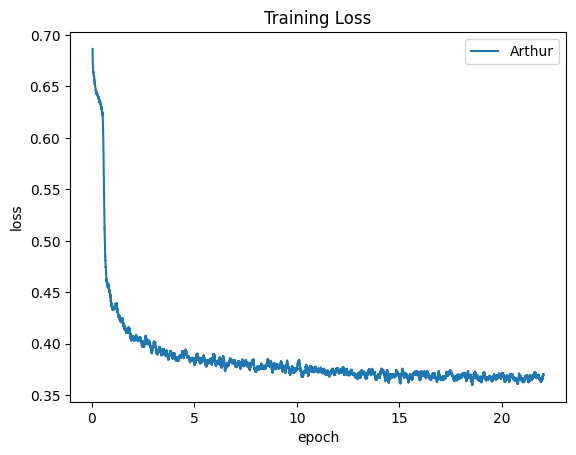

In [23]:
import pandas as pd
df1 = pd.read_csv('/sdf/data/neutrino/summer25/ktwall/logs_Arthur1/delaunay-Arthur1-GPUtrain.csv')
rolling_1 = df1.rolling(200).mean()
plt.plot(rolling_1['epoch'], rolling_1['loss'], label = 'Arthur')
plt.xlabel('epoch')
#plt.yscale('log')
plt.ylabel('loss')
plt.title('Training Loss')
plt.legend()
#lmao zero loss surely this means that our model is working perfectly!!!

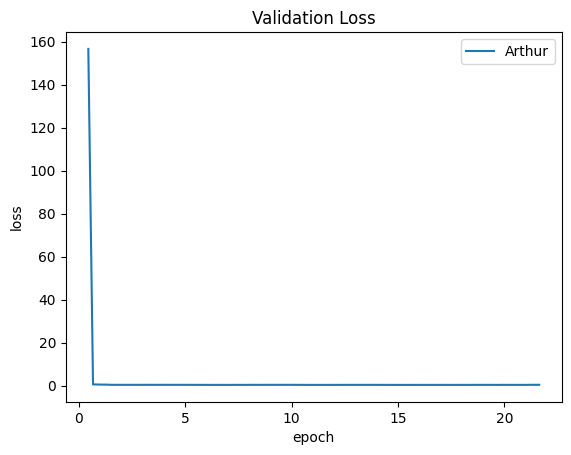

In [30]:
df2 = pd.read_csv('/sdf/data/neutrino/summer25/ktwall/logs_Arthur1/delaunay-Arthur1-GPUval.csv')
rolling_2 = df2.rolling(5).mean()
plt.plot(rolling_2['epoch'], rolling_2['loss'], label = 'Arthur')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Validation Loss')
plt.legend()

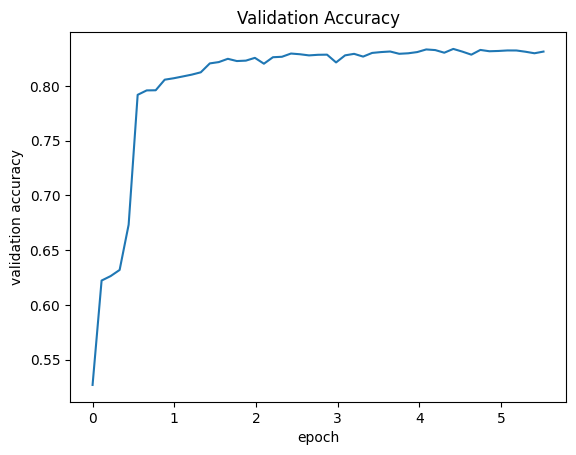

In [21]:
plt.plot(valid_epochs, validation_accuracy)

plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Validation Accuracy")
plt.savefig("Arthur_validation.png")

In [21]:
def run_inference(model, test_loader):
    model.eval()
    with torch.no_grad():
        i = 0
        total_correct = 0
        for data in test_loader:
            out = model(data.x, data.edge_index)
            inference = F.log_softmax(out, dim=1)
            n_correct = torch.sum(inference.argmax(dim=1) == (data.y))
            i += len(data.y)
            total_correct += n_correct
    return(total_correct / i)

In [43]:
run_inference(ModelArthur1, testing_data_loader)

tensor(0.8418)

In [73]:
#save the model weights. 
model_weights = ModelArthur1.state_dict()
torch.save(model_weights, 'final_arthur1_train90_weights.pth')

In [19]:
#load in the weights so we don't have to do this all again:
Arthur1_state_dict = torch.load('/sdf/data/neutrino/summer25/ktwall/logs_Arthur1/delaunay-Arthur1-GPU-train90.pth', weights_only = True, map_location=torch.device('cpu'))
ModelArthur1_preload = Arthur1(in_channels = 3, hc1 = 20, hc2 = 40, hc3 = 50, fc1 = 25, fc2 = 12, fc3 = 6, out_channels = 2)
ModelArthur1_preload.load_state_dict(Arthur1_state_dict)
ModelArthur1_preload.eval()

Arthur1(
  (convolution1): GCNConv(3, 20)
  (bn1): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (convolution2): GCNConv(20, 40)
  (bn2): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (convolution3): GCNConv(40, 50)
  (bn3): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear1): Linear(in_features=50, out_features=25, bias=True)
  (linear2): Linear(in_features=25, out_features=12, bias=True)
  (linear3): Linear(in_features=12, out_features=6, bias=True)
  (linear4): Linear(in_features=6, out_features=2, bias=True)
)

In [22]:
run_inference(ModelArthur1_preload, testing_data_loader)

tensor(0.8487)

In [37]:
#lets investigate a little bit. How is our labeling actually looking?

inference_list = []
graph_list = []
node_to_graph = []

for data in testing_data_loader:
    graph_list.append(data)
    node_to_graph.append(data.batch)
    out = ModelArthur1_preload(data.x, data.edge_index)
    inference = F.log_softmax(out, dim=1)
    inference_list.append(inference.argmax(dim=1))

In [38]:
#map back to graphs:
full_graphs_list = []
graph_finder = []
grouped_nodes_list = []
for i, nodes in enumerate(graph_list):
    labels = (inference_list[i]).numpy()
    node_array = (nodes.x).numpy()
    truth_labels = (nodes.y).numpy()
    batch_array = (nodes.batch).numpy()
    occupancy = (nodes.occupancy).numpy()
    file_no_arr = (nodes.file_number).numpy()
    graph_no_arr = (nodes.graph_number).numpy()
    grouped_nodes = np.column_stack((node_array,batch_array, truth_labels, labels)) #node info, graph #, truth label, inferences label
    grouped_nodes_list.append(grouped_nodes)
    for graph_n in np.unique(grouped_nodes[:,-3]):
        file = file_no_arr[int(graph_n)]
        graph_number = graph_no_arr[int(graph_n)]
        graph_n_subarray = grouped_nodes[grouped_nodes[:,-3] == graph_n]
        full_graphs_list.append(graph_n_subarray)
        graph_finder.append((file,graph_number))

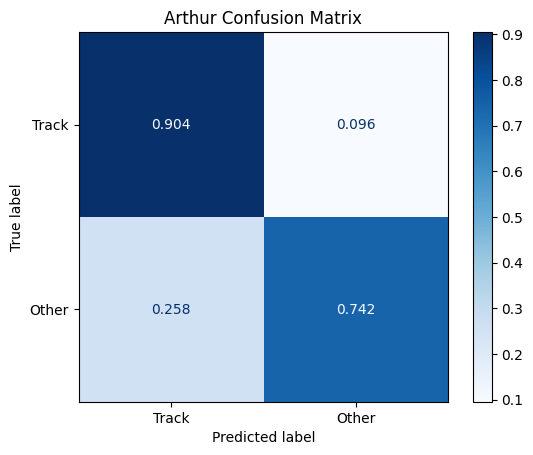

In [39]:
full_stack = np.vstack(grouped_nodes_list)
np.shape(full_stack)
y_true = full_stack[:,-2]
y_pred = full_stack[:,-1]
label_names = ['Track', 'Other']
cm = confusion_matrix(y_true, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap=plt.cm.Blues, values_format=".3f")
plt.title('Arthur Confusion Matrix')
plt.show()

Text(0, 0.5, 'x [mm]')

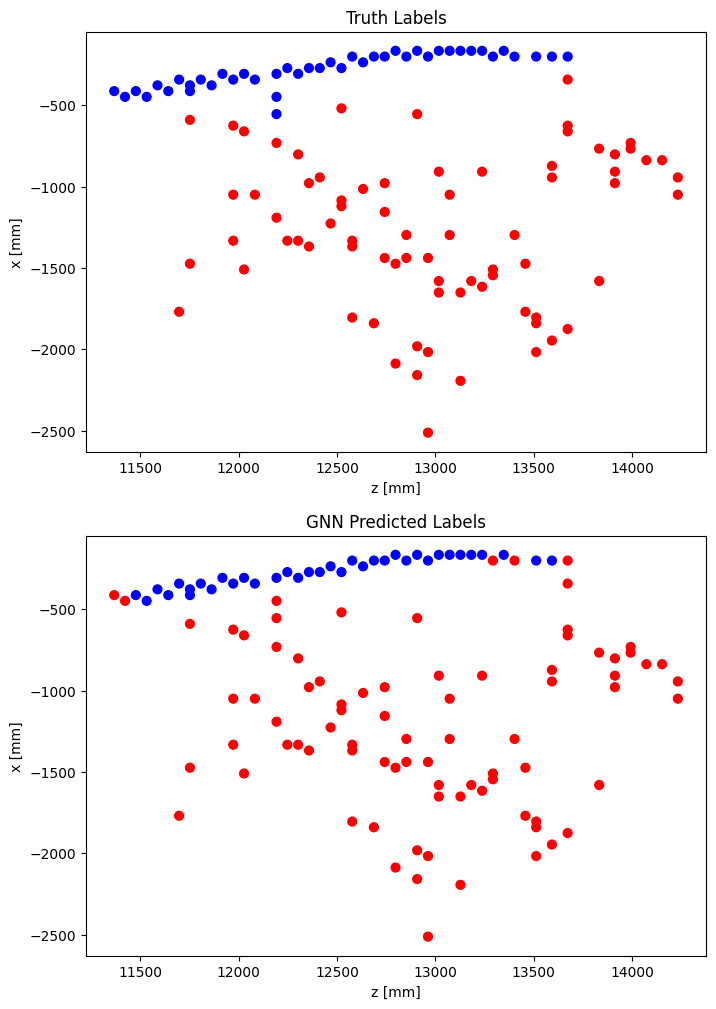

In [51]:
#lets see how it is doing!
#selected cluster, can now take a look at the truth labels.
cluster_n = 9455 #row_indices[0]
nodes = full_graphs_list[cluster_n]
zs = nodes[:,0]
xs = nodes[:,1]
true_labels = nodes[:,-2]
inference_labels = nodes[:,-1]

truth_colors = []
for true_label in true_labels:
    if true_label == 0:
        truth_colors.append('blue')
    else:
        truth_colors.append('red')
        
inference_colors = [] 
for inf_label in inference_labels:
    if inf_label == 0:
        inference_colors.append('blue')
    else:
        inference_colors.append('red')

fig, ((ax1), (ax2)) = plt.subplots(2, 1, figsize=(8,12))

sc1 = ax1.scatter(zs, xs, s = 40, c = truth_colors)
#ax1.set_xlim((11224.75,14376.25))
ax1.set_title(f'Truth Labels')
#ax1.set_ylim((-2629.5251251273958,-47.99425433145693))
ax1.set_xlabel("z [mm]")
ax1.set_ylabel("x [mm]")

#11224.75 14376.25
#-2629.5251251273958 -47.99425433145693


sc2 = ax2.scatter(zs, xs, s = 40, c = inference_colors)
ax2.set_title(f'GNN Predicted Labels')
#ax2.set_xlim((11224.75,14376.25))
#ax2.set_ylim((-2629.5251251273958,-47.99425433145693))
ax2.set_xlabel("z [mm]")
ax2.set_ylabel("x [mm]")


In [50]:
cluster_ns = (np.array(graph_finder))[:,1]
np.where(cluster_ns == 1789)
graph_finder[9455]

(np.int64(2553), np.int64(1789))

In [44]:
cluster_ns = (np.array(graph_finder))[:,1]
np.where(cluster_ns == 1789)

(array([ 2858,  3094,  9455, 10048, 12048]),)

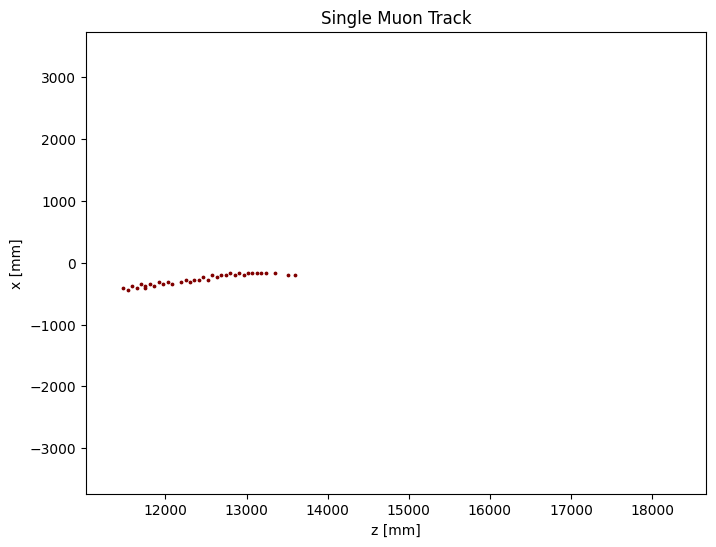

In [59]:
cluster_n = 9455 #row_indices[0]
nodes = full_graphs_list[cluster_n]
track_nodes = nodes[nodes[:,-1] == 0]
zs = track_nodes[:,0]
xs = track_nodes[:,1]
true_labels = nodes[:,-2]
inference_labels = nodes[:,-1]

inference_colors = [] 
for inf_label in inference_labels:
    if inf_label == 0:
        inference_colors.append('blue')
    else:
        inference_colors.append('red')
        


plt.figure(figsize=(8, 6))
plt.scatter(zs, xs, s = 3, c = 'maroon')
plt.xlim((np.float64(11020.5), np.float64(18665.5)))
plt.ylim((np.float64(-3736.1161924280314), np.float64(3736.1161924280314)))
plt.xlabel('z [mm]')
plt.ylabel('x [mm]')
plt.title('Single Muon Track')
plt.savefig('presentation_plots/full_filter.png')